# LC

[![Version]](https://github.com/juntyr/LC-framework/tree/03008848201c3e6067809dafe03e028e6233e360)
[![Citation]](https://doi.org/10.48550/arxiv.2407.15037)
[![Source]](https://github.com/burtscher/LC-framework)
[![Pitch]](pitches/e-lc.pdf)

[Version]: https://img.shields.io/badge/v2025+-grey?style=for-the-badge
[Citation]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[Source]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[Pitch]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

LC [^lc] is a framework for constructing modular lossless and lossy compressors from a collection of preprocessors and components. LC provides cross-platform compression that is guaranteed to produce the same results on CPUs and GPUs. LC supports pointwise absolute, relative, and normalised error bounds using quantisation-based preprocessors.

LC's native implementation [^lcgh] also provides tools to find optimal compression pipelines using exhaustive search and genetic algorithms.

The implementation in `numcodecs-wasm-lc` provides a compressor that can be configured with the preprocessor and components that it should consist of.

[^lc]: Fallin, A., & Burtscher, M. (2024). Lessons learned on the path to guaranteeing the error bound in lossy quantizers. *arXiv*. Available from: [doi:10.48550/arxiv.2407.15037](https://doi.org/10.48550/arxiv.2407.15037).

[^lcgh]: <https://github.com/burtscher/LC-framework>

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `Lc` compressor

In [4]:
from numcodecs_wasm_lc import Lc

In [5]:
?Lc

Init signature: Lc(components, _version='0.1.0', preprocessors=[])
Docstring:     
Codec providing compression using LC

Parameters
----------
components : ...
    LC components
_version : ..., optional, default = "0.1.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
preprocessors : ..., optional, default = []
    LC preprocessors
File:           ~/egu26-compression-sc2.5/.venv/lib/python3.13/site-packages/numcodecs_wasm_lc/__init__.py
Type:           ABCMeta
Subclasses:     

### Available Preprocessors

- `NUL`: no-op, `{"id": "NUL"}`
- `LOR`: 1D Lorenzo predictor over 32 bit signed integers, e.g. `{"id": "LOR", "dtype": "i32"}`
- `QUANT`: lossy absolute (`ABS`) / relative (`REL`) / normalised-absolute (`NOA`, also known as range-relative) error-bounded quantisation for 32/64 bit floating point values with zero (`0`) or random (`R`) decorrelation, e.g. `{"id": "QUANT", "dtype": "f64", "kind": "ABS", "error_bound": 0.1, "decorrelation": "R"}`

The complete list of supported preprocessors can be inspected by providing an invalid id:

In [6]:
try:
    Lc(preprocessors=[{"id": "???"}])
except Exception as err:
    print(err)


 1 | {"preprocessors":[{"id":"???"}]}
   |                              ^ unknown variant `???`, expected one of `NUL`, `LOR`, `QUANT` at line 1 column 29



### Available Components [^components][^efficient]

- `NUL`: no-op, `{"id": "NUL"}`
- Mutators:
    - `TCMS`: convert from integer two's complement to sign-magnitude representation for 1/2/4/8-byte values, e.g. `{"id": "TCMS", "size": 1}`
    - `TCNB`: convert from integer two's complement to negabinary representation for 1/2/4/8-byte values, e.g. `{"id": "TCNB", "size": 2}`
    - `DBEFS`: convert from IEEE 754 floating point to debiased exponent fraction sign representation for 4/8-byte values, e.g. `{"id": "DBEFS", "size": 4}`
    - `DBESF`: convert from IEEE 754 floating point to debiased exponent sign fraction representation for 4/8-byte values, e.g. `{"id": "DBESF", "size": 8}`
- Shufflers:
    - `BIT`: bit shuffle for 1/2/4/8-byte values, e.g. `{"id": "BIT", "size": 1}`
    - `TUPL`: tuple shuffle for 2/3/4/6/8/12-element tuples of 1/2/4/8-byte values, e.g. `{"id": "TUPL", "size": "12_1"}`
- Predictors:
    - `DIFF`: delta for 1/2/4/8-byte values, e.g. `{"id": "DIFF", "size": 2}`
    - `DIFFMS`: delta as sign-magnitude for 1/2/4/8-byte values, e.g. `{"id": "DIFFMS", "size": 4}`
    - `DIFFNB`: delta as negabinary for 1/2/4/8-byte values, e.g. `{"id": "DIFFNB", "size": 8}`
- Reducers:
    - `CLOG`: chunked leading-zero-bit elimination for 1/2/4/8-byte values, e.g. `{"id": "CLOG", "size": 1}`
    - `HCLOG`: hybrid chunked leading-zero-bit elimination for 1/2/4/8-byte values, e.g. `{"id": "HCLOG", "size": 2}`
    - `RARE`: repeated adaptive redundancy elimination for 1/2/4/8-byte values, e.g. `{"id": "RARE", "size": 4}`
    - `RAZE`: repeated adaptive zero elimination for 1/2/4/8-byte values, e.g. `{"id": "RAZE", "size": 8}`
    - `RLE`: run-length encoding for 1/2/4/8-byte values, e.g. `{"id": "RLE", "size": 1}`
    - `RRE`: repeated redundancy elimination for 1/2/4/8-byte values, e.g. `{"id": "RRE", "size": 2}`
    - `RZE`: repeated zero elimination for 1/2/4/8-byte values, e.g. `{"id": "RZE", "size": 4}`

The complete list of supported components can be inspected by providing an invalid id:

[^components]: Azami, N. & Burtscher, M. (2025). Identifying Important Data Transformations for Synthesizing Effective Lossless Compressors. *2025 IEEE International Symposium on Performance Analysis of Systems and Software (ISPASS)*, 286–296. Available from: [doi:10.1109/ispass64960.2025.00034](https://doi.org/10.1109/ispass64960.2025.00034) and <https://userweb.cs.txstate.edu/~burtscher/papers/ispass25.pdf>.

[^efficient]: Azami, N., Fallin, A., & Burtscher, M. (2025). Efficient Lossless Compression of Scientific Floating-Point Data on CPUs and GPUs. *ASPLOS '25: Proceedings of the 30th ACM International Conference on Architectural Support for Programming Languages and Operating Systems*, 1, 395–409. Available from: [doi:10.1145/3669940.3707280](https://doi.org/10.1145/3669940.3707280) and <https://userweb.cs.txstate.edu/~burtscher/papers/asplos25.pdf>.

In [7]:
try:
    Lc(components=[{"id": "???"}])
except Exception as err:
    print(err)


 1 | {"components":[{"id":"???"}]}
   |                           ^ unknown variant `???`, expected one of `NUL`, `TCMS`, `TCNB`, `DBEFS`, `DBESF`, `BIT`, `TUPL`, `DIFF`, `DIFFMS`, `DIFFNB`, `CLOG`, `HCLOG`, `RARE`, `RAZE`, `RLE`, `RRE`, `RZE` at line 1 column 26



## Bounding the pointwise absolute error

LC can bound the absolute error using the `ABS` kind of the `QUANT` preprocessor:

In [8]:
eb_abs = 1.0

Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "ABS",
            "error_bound": eb_abs,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

Lc(preprocessors=[{'id': 'QUANT', 'dtype': 'f64', 'kind': 'ABS', 'error_bound': 1.0, 'threshold': None, 'decorrelation': '0'}], components=[{'id': 'BIT', 'size': 8}, {'id': 'RLE', 'size': 8}], _version='0.1.0')

## Bounding the range-relative error

LC can bound the range-relative error using the `NOA` kind of the `QUANT` preprocessor:

In [9]:
eb_range_rel = 0.01  # 1% of max(data) - min(data)

Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "NOA",
            "error_bound": eb_range_rel,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

Lc(preprocessors=[{'id': 'QUANT', 'dtype': 'f64', 'kind': 'NOA', 'error_bound': 0.01, 'threshold': None, 'decorrelation': '0'}], components=[{'id': 'BIT', 'size': 8}, {'id': 'RLE', 'size': 8}], _version='0.1.0')

## Bounding the pointwise relative error

LC can bound the relative error using the `REL` kind of the `QUANT` preprocessor:

In [10]:
eb_rel = 0.01

Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "REL",
            "error_bound": eb_rel,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

Lc(preprocessors=[{'id': 'QUANT', 'dtype': 'f64', 'kind': 'REL', 'error_bound': 0.01, 'threshold': None, 'decorrelation': '0'}], components=[{'id': 'BIT', 'size': 8}, {'id': 'RLE', 'size': 8}], _version='0.1.0')

## Preserving Missing Values

NaN values and infinities are automatically preserved by LC.

## Example

In [11]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [12]:
eb_abs = 0.1  # 0.1 K

codec = Lc(
    preprocessors=[
        {
            "id": "QUANT",
            "dtype": "f64",
            "kind": "ABS",
            "error_bound": eb_abs,
            "decorrelation": "0",
        }
    ],
    components=[
        # e.g. bit shuffle and run-length encoding over 8 byte floating point
        {"id": "BIT", "size": 8},
        {"id": "RLE", "size": 8},
    ],
)

In [13]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

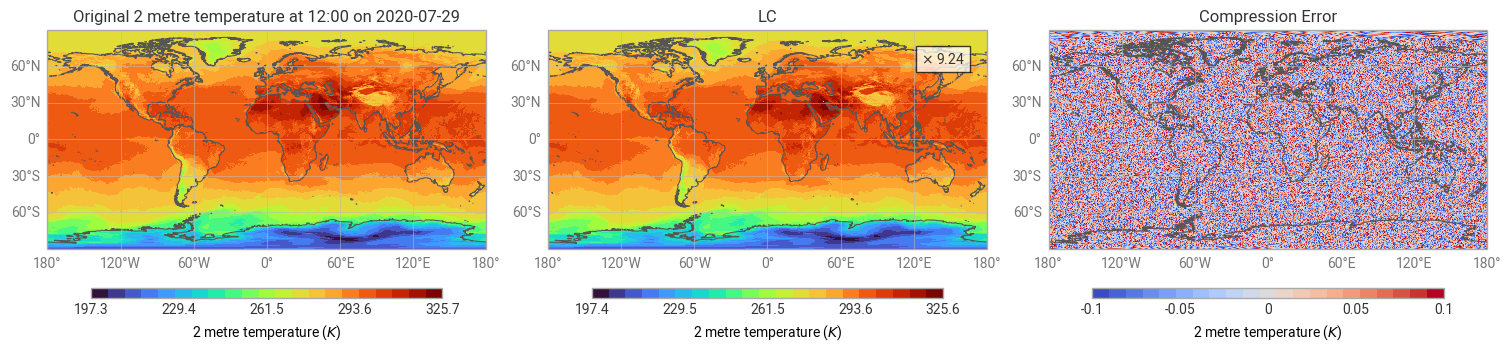

In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(da_dec, fig.add_map(0, 1), title="LC", cr=da.nbytes / np.array(da_enc).nbytes)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()